In [1]:
import torch
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load VGG19
vgg = models.vgg19(pretrained=True).features.to(device).eval()

for param in vgg.parameters():
    param.requires_grad = False


# Image loader
loader = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor()
])

def load_image(path):
    image = Image.open(path).convert("RGB")
    image = loader(image).unsqueeze(0)
    return image.to(device)


# Feature extraction
def get_features(image, model):

    layers = {
        '0':'conv1_1',
        '5':'conv2_1',
        '10':'conv3_1',
        '19':'conv4_1',
        '21':'conv4_2',
        '28':'conv5_1'
    }

    features = {}
    x = image

    for name, layer in model._modules.items():
        x = layer(x)

        if name in layers:
            features[layers[name]] = x

    return features


# Gram Matrix
def gram_matrix(tensor):

    b,c,h,w = tensor.size()

    tensor = tensor.view(c, h*w)

    gram = torch.mm(tensor, tensor.t())

    return gram

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 202MB/s]


In [3]:
content_img = load_image("/content/me.jpeg")
style_img = load_image("/content/starry-Night.jpg")

content_features = get_features(content_img, vgg)
style_features = get_features(style_img, vgg)

style_grams = {layer: gram_matrix(style_features[layer]) for layer in style_features}

Step: 0 Loss: 6030786.0
Step: 50 Loss: 513097.5625
Step: 100 Loss: 346438.75
Step: 150 Loss: 268767.25
Step: 200 Loss: 213337.5625
Step: 250 Loss: 169950.859375


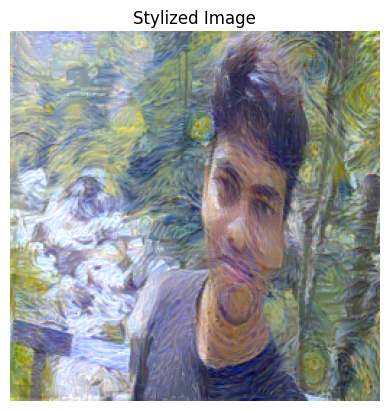

In [4]:
generated = content_img.clone().requires_grad_(True)

style_weight = 1e6
content_weight = 1

optimizer = optim.Adam([generated], lr=0.003)

steps = 300

for step in range(steps):

    gen_features = get_features(generated, vgg)

    content_loss = torch.mean(
        (gen_features['conv4_2'] - content_features['conv4_2'])**2
    )

    style_loss = 0

    for layer in style_grams:

        gen_feature = gen_features[layer]
        gen_gram = gram_matrix(gen_feature)
        style_gram = style_grams[layer]

        _,c,h,w = gen_feature.shape

        layer_style_loss = torch.mean((gen_gram-style_gram)**2)

        style_loss += layer_style_loss/(c*h*w)

    total_loss = content_weight*content_loss + style_weight*style_loss

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    if step % 50 == 0:
        print("Step:",step,"Loss:",total_loss.item())


output = generated.cpu().clone().detach().squeeze(0)

plt.imshow(output.permute(1,2,0))
plt.axis("off")
plt.title("Stylized Image")
plt.show()